<a href="https://colab.research.google.com/github/Otto-gits/M4AI/blob/main/Code/pca_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import torch
import math
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
seed = 10
g_cpu = torch.Generator() # create a random number generator
g_cpu.manual_seed(seed)      # set the seed so we get the same values



In [12]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=0.5, std=1.0)])

train_dataset = datasets.MNIST(root='../data', train=True,
                               download=True, transform=transform)
test_dataset = datasets.MNIST(root='../data', train=False,
                              download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.32MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 11.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


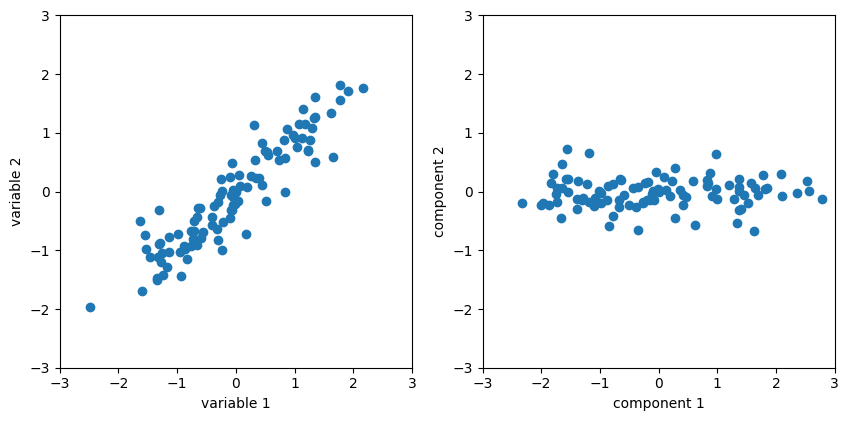

In [9]:
m = 100
n = 2
mu = torch.zeros(n)
std = torch.tensor( [1, 0.5] )
W = torch.tensor( [[ 1, 0.8], [0.25, 0.9]] )
X = torch.zeros(m, n)
for i in torch.arange(0, m-1):
  X[i,:] = torch.normal( mu, std, generator=g_cpu) @ W

U,s,Vh = torch.linalg.svd( X )
V = torch.transpose(Vh, 0, 1)
T = X @ V

# plot
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10.0, 5.0)

ax[0].scatter(X[:,0], X[:,1])
ax[0].set_xlim(-3, 3)
ax[0].set_ylim(-3, 3)
ax[0].set_xlabel('variable 1')
ax[0].set_ylabel('variable 2')
ax[0].set_aspect('equal')

ax[1].scatter(T[:,0], T[:, 1])
ax[1].set_xlim(-3, 3)
ax[1].set_ylim(-3, 3)
ax[1].set_xlabel('component 1')
ax[1].set_ylabel('component 2')
ax[1].set_aspect('equal')

